# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Fundamentos**
#### **2.3 — Dataset Dados Financeiros**

> Neste notebook vamos explorar **datasets** aplicadas a **dados financeiros**, um passo parao treino de modelos baseados em **Redes Neuronais Recorrentes** (RNNs), como as **LSTM**.  
>  
> Será demonstrado como recolher dados de ativos financeiros, a partir da **Yahoo Finance**, procedendo também à sua **Normalização**.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

In [1]:
#Instala e importa bibliotecas
!pip install yfinance --quiet

import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd

In [2]:
#Carregar dados da Apple (últimos 6 meses)
dados = yf.download("AAPL", period="6mo")

/tmp/ipykernel_55074/1998308021.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download("AAPL", period="6mo")
[*********************100%***********************]  1 of 1 completed


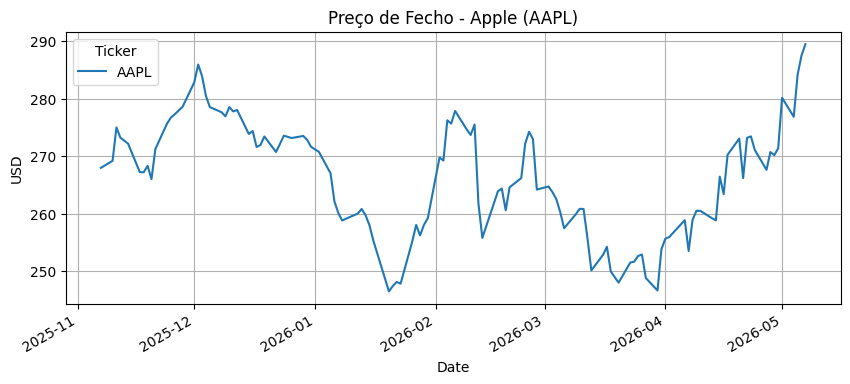

In [3]:
#Mostrar apenas o fecho
dados['Close'].plot(title='Preço de Fecho - Apple (AAPL)', figsize=(10, 4), grid=True)
plt.ylabel('USD')
plt.show()

In [4]:
#Selecionar Abertura, Máximo, Mínimo e Fecho
valores = dados[['Open', 'High', 'Low', 'Close']]

/tmp/ipykernel_55074/2459678251.py:4: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(valores.index, valores[coluna], label=coluna)


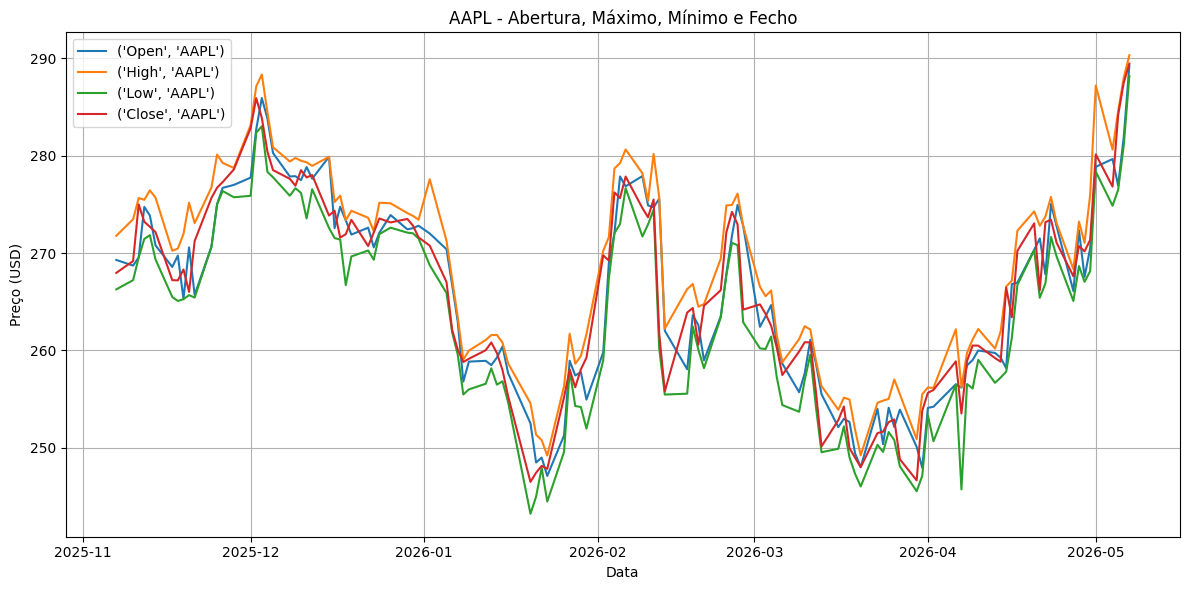

In [5]:

#Plot conjunto
plt.figure(figsize=(12, 6))
for coluna in valores.columns:
    plt.plot(valores.index, valores[coluna], label=coluna)
plt.title('AAPL - Abertura, Máximo, Mínimo e Fecho')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **Vamos Aplicar Normalização**
#### **Ver RNN_Session02_Script02_Normalização.ipynb**

>  Consideramos MinMaxScaler, StandardScaler, RobustScaler











In [6]:
#Aplicar Normalizações
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


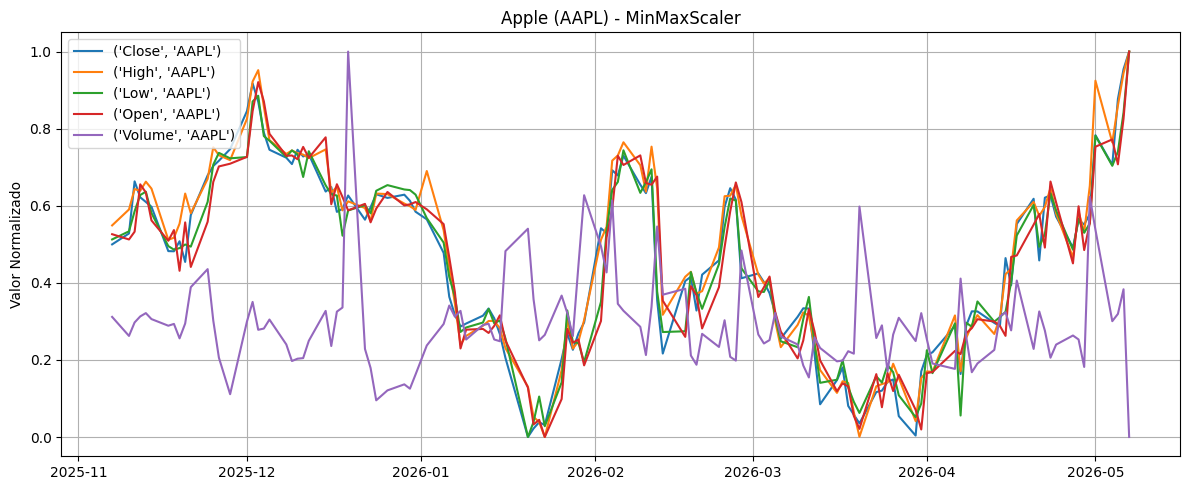

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


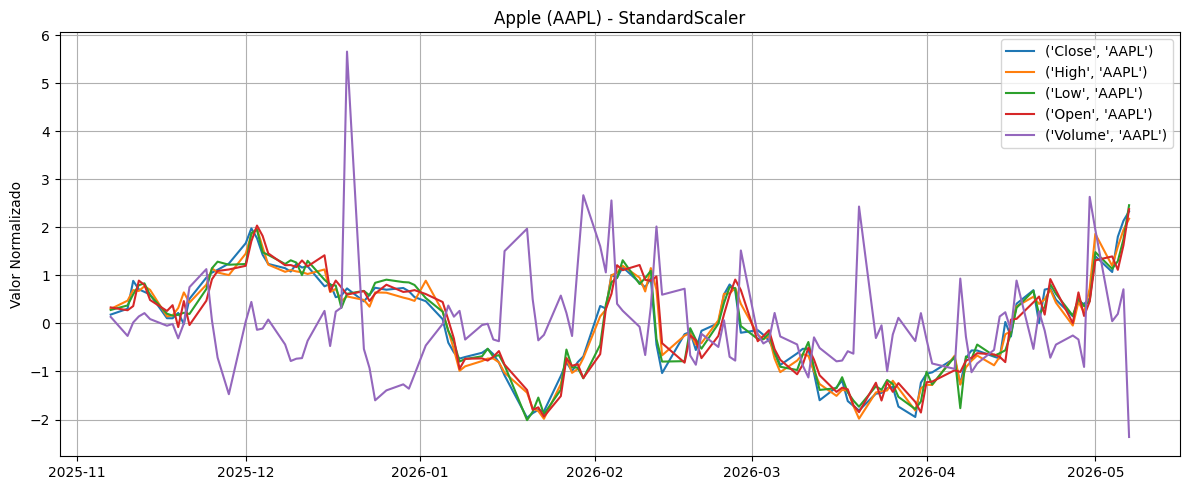

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


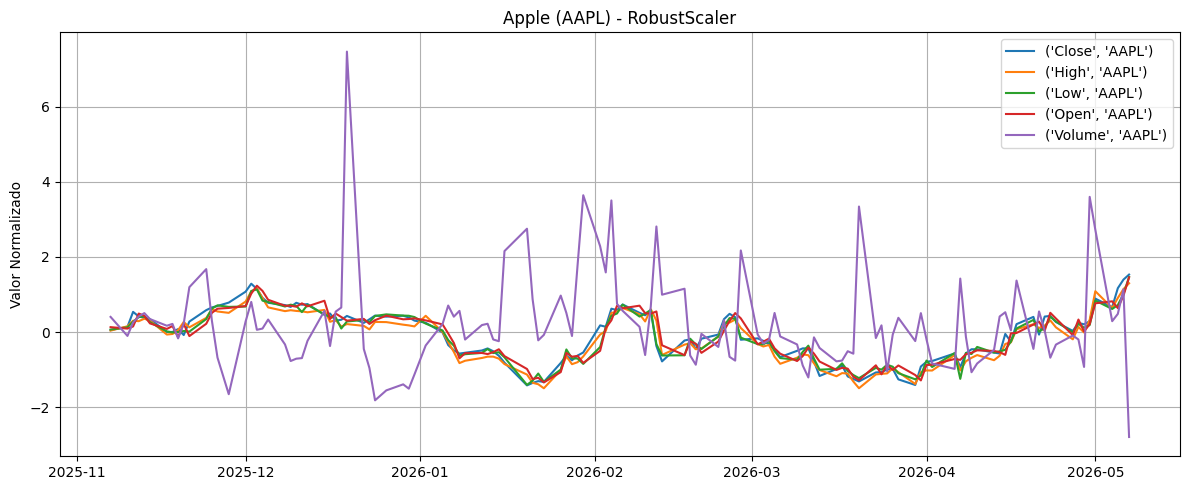

In [7]:
#Aplicar e plotar cada normalização
for nome, scaler in scalers.items():
    dados_scaled = scaler.fit_transform(dados)
    df_scaled = pd.DataFrame(dados_scaled, index=dados.index, columns=dados.columns)

    # 📊 Plot
    plt.figure(figsize=(12, 5))
    for coluna in df_scaled.columns:
        plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)
    plt.title(f'Apple (AAPL) - {nome}')
    plt.ylabel('Valor Normalizado')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()